In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")

df = pd.read_csv(os.path.join(path,"House Price Prediction Dataset.csv"))

Using Colab cache for faster access to the 'house-price-prediction-dataset' dataset.


In [3]:
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


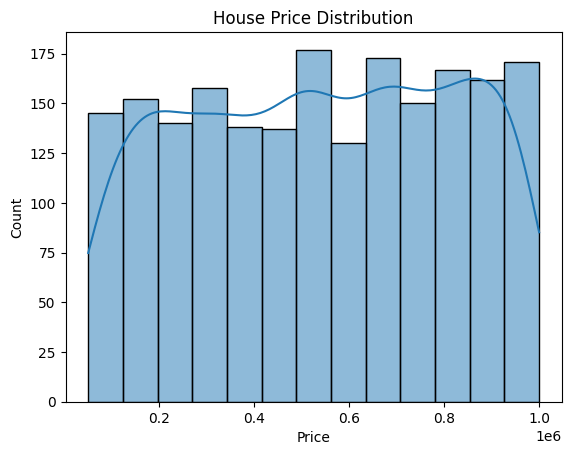

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Price"], kde=True)
plt.title("House Price Distribution")
plt.show()

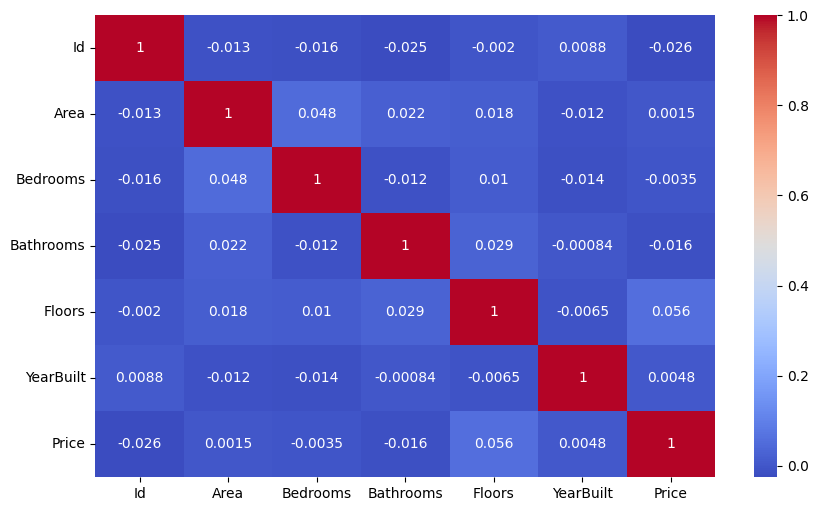

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [8]:
df = df.replace({'Yes':1,'No':0})

/tmp/ipykernel_243/3001428410.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes':1,'No':0})


In [9]:
X = df.drop(['Id','Price'], axis=1)
y = df['Price']

In [10]:
X = pd.get_dummies(X)

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error,r2_score

print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))

RMSE: 279859.72583784326
R2 Score: -0.006717808430749761


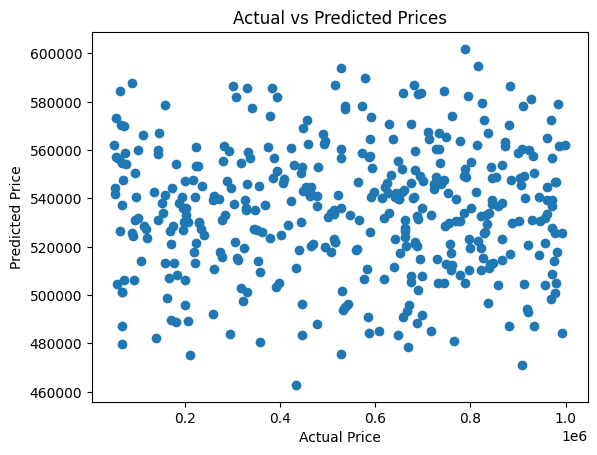

In [15]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [16]:
new_house = pd.DataFrame([[2000,3,2,2,2015,1]],
                         columns=['Area','Bedrooms','Bathrooms','Floors','YearBuilt','Garage'])

In [17]:
new_house = new_house.reindex(columns=X.columns, fill_value=0)

In [18]:
predicted_price = model.predict(new_house)

In [19]:
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 548927.8932365705


In [20]:
from xgboost import XGBRegressor

In [21]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE: 320133.48895734106


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 102485450752.0
RMSE: 320133.48895734106
MAE: 273211.75
R2 Score: -0.317313551902771


In [24]:
import pickle

with open("house_model.pkl","wb") as f:
    pickle.dump(model,f)

In [25]:
from google.colab import files
files.download("house_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("house_model.pkl","rb"))

st.title("House Price Prediction")

area = st.number_input("Area")
bedrooms = st.number_input("Bedrooms")
bathrooms = st.number_input("Bathrooms")
stories = st.number_input("Stories")
parking = st.number_input("Parking")

if st.button("Predict"):
    prediction = model.predict([[area,bedrooms,bathrooms,stories,parking]])
    st.success(f"Predicted Price: {prediction[0]}")

Writing app.py


In [28]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 108.9 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇

⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.46.25:8501

